# Subset Analysis

This notebook analyzes the differences between model ranking across the full dataset and model ranking for each subset across datasets with pre-defined subsets.

Import packages.

In [183]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from utils.data import (
    Dataset,
    MetadataKey,
    get_metadata_mask,
    get_unique_metadata_values,
)
from utils.model import load_eval_results, compute_ranking
from utils.path import resolve_dataset_path, build_plot_path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


View each dataset's columns to determine which ones have pre-defined subsets.

In [184]:
datasets = [d.value for d in Dataset]

for dataset in datasets:
    file_path = resolve_dataset_path(dataset)
    df = pd.read_json(file_path)
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

DS-1000: 1000 instances


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


MATH: 5000 instances


,problem,level,type,solution,subset
0,How many vertical asymptotes does the graph of...,Level 3,Algebra,The denominator of the rational function facto...,algebra
1,What is the positive difference between $120\%...,Level 1,Algebra,One hundred twenty percent of 30 is $120\cdot3...,algebra
2,Find $x$ such that $\lceil x \rceil + x = \dfr...,Level 4,Algebra,"First, we note that $x$ must be positive, sinc...",algebra
3,Evaluate $i^5+i^{-25}+i^{45}$.,Level 5,Algebra,We have $i^5 = i^4\cdot i = 1\cdot (i) = i$. ...,algebra
4,"If $2^8=4^x$, what is the value of $x$?",Level 1,Algebra,Rewrite $4$ as $2^2$ to find $4^x=2^{2x}$. Si...,algebra


MMLU: 14042 instances


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1


## Inter-Subset Analysis

For each dataset with pre-defined subsets, do the following:
- Compute the global model ranking
- Compute the each subset's local model ranking
- Compute the Kendall's Tau between the global model ranking and each subset's local model ranking

### DS-1000

Load the raw dataset and evaluation results.

In [185]:
dataset = Dataset.DS_1000
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
models = eval_results_df.columns.tolist()

print(f"Number of instances: {len(dataset_df)}")
display(dataset_df.head())
display(eval_results_df.head())

Number of instances: 1000


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


Compute each model's average performance across the entire dataset.

In [186]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)

print(f"Number of models: {len(mean_accuracy_df)}")
mean_accuracy_df.round(3).head()

Number of models: 3


,model,accuracy
2,gpt-4o-2024-08-06,0.598
1,gpt-3.5-turbo-0613,0.387
0,deepseek-coder-6.7b-base,0.312


Compute the global model ranking.

In [187]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

deepseek-coder-6.7b-base: 3
gpt-3.5-turbo-0613: 2
gpt-4o-2024-08-06: 1


Count the number of subsets where the local model ranking differs from the global model ranking.

In [188]:
subset_col = MetadataKey.LIBRARY
subsets = get_unique_metadata_values(dataset_df, subset_col)
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    print(f"Subset: {len(subset_eval_results_df)} instances. Ranking: {subset_ranking}")
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Subsets: {'Tensorflow', 'Sklearn', 'Pytorch', 'Pandas', 'Matplotlib', 'Scipy', 'Numpy'}
Subset: 45 instances. Ranking: [3 2 1]
Subset: 115 instances. Ranking: [2 3 1]
Subset: 68 instances. Ranking: [3 2 1]
Subset: 291 instances. Ranking: [3 2 1]
Subset: 155 instances. Ranking: [3 2 1]
Subset: 106 instances. Ranking: [3 2 1]
Subset: 220 instances. Ranking: [3 2 1]
Total number of subsets: 7
Subsets that differ from the global ranking: 1


Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [189]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

results = []

for subset in tqdm(subsets, **kwargs):
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": len(subset_eval_results_df),
        }
    )

results_df = pd.DataFrame(results)
print(f"Number of subsets: {len(results_df)}")
results_df.head()

Computing model rankings: 100%|██████████| 7/7 [00:00<00:00, 665.93subset/s]

Number of subsets: 7


,subset,ranking,kendall_tau,n_instances
0,Tensorflow,"[3, 2, 1]",1.000000,45
1,Sklearn,"[2, 3, 1]",0.333333,115
2,Pytorch,"[3, 2, 1]",1.000000,68
3,Pandas,"[3, 2, 1]",1.000000,291
4,Matplotlib,"[3, 2, 1]",1.000000,155


Plot the distribution of Kendall's Taus between each subset's model ranking and the global model ranking.

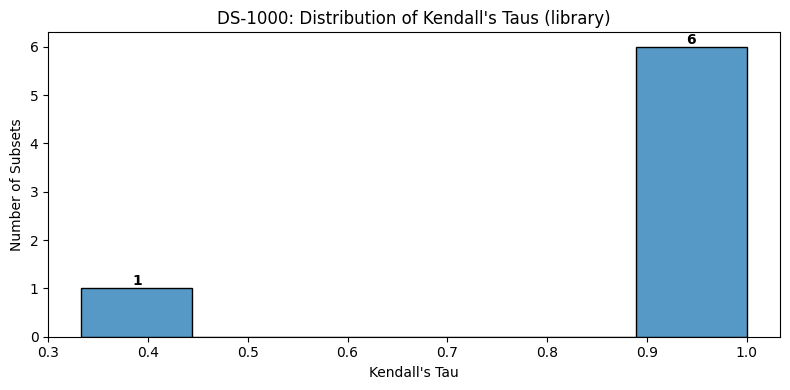

In [190]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=results_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel("Number of Subsets")
ax.set_title(f"{dataset}: Distribution of Kendall's Taus ({subset_col})")

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()

analysis = "subset_analysis"
plot_name = f"kendall_tau_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### MATH

Load the raw dataset and evaluation results.

In [191]:
dataset = Dataset.MATH
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
# eval_results_df = eval_results_df.drop(columns=["gpt-4o-mini-2024-07-18"])
models = eval_results_df.columns.tolist()

print(f"Number of instances: {len(dataset_df)}")
display(dataset_df.head())
display(eval_results_df.head())

Number of instances: 5000


,problem,level,type,solution,subset
0,How many vertical asymptotes does the graph of...,Level 3,Algebra,The denominator of the rational function facto...,algebra
1,What is the positive difference between $120\%...,Level 1,Algebra,One hundred twenty percent of 30 is $120\cdot3...,algebra
2,Find $x$ such that $\lceil x \rceil + x = \dfr...,Level 4,Algebra,"First, we note that $x$ must be positive, sinc...",algebra
3,Evaluate $i^5+i^{-25}+i^{45}$.,Level 5,Algebra,We have $i^5 = i^4\cdot i = 1\cdot (i) = i$. ...,algebra
4,"If $2^8=4^x$, what is the value of $x$?",Level 1,Algebra,Rewrite $4$ as $2^2$ to find $4^x=2^{2x}$. Si...,algebra


,dart-math-llama3-8b-uniform,deepseek-math-7b-instruct,gpt-4o-mini-2024-07-18,Llama-3-8B-Instruct,Llama-3.1-8B-Instruct
0,1,1,1,1,1
1,1,1,1,0,1
2,0,1,1,1,0
3,1,0,1,0,1
4,1,1,1,1,1


Compute each model's average performance across the entire dataset.

In [192]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)

print(f"Number of models: {len(mean_accuracy_df)}")
mean_accuracy_df.round(3).head()

Number of models: 5


,model,accuracy
2,gpt-4o-mini-2024-07-18,0.701
4,Llama-3.1-8B-Instruct,0.497
1,deepseek-math-7b-instruct,0.470
0,dart-math-llama3-8b-uniform,0.453
3,Llama-3-8B-Instruct,0.301


Compute the global model ranking.

In [193]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

dart-math-llama3-8b-uniform: 4
deepseek-math-7b-instruct: 3
gpt-4o-mini-2024-07-18: 1
Llama-3-8B-Instruct: 5
Llama-3.1-8B-Instruct: 2


Count the number of subsets where the local model ranking differs from the global model ranking.

In [194]:
subset_col = "subset"
subsets = dataset_df[subset_col].unique()

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Total number of subsets: 7
Subsets that differ from the global ranking: 4


Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [195]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

results_df = pd.DataFrame(results)
print(f"Number of subsets: {len(results_df)}")
results_df.head()

Computing model rankings: 100%|██████████| 7/7 [00:00<00:00, 832.06subset/s]

Number of subsets: 7


,subset,ranking,kendall_tau,n_instances
0,algebra,"[4, 3, 1, 5, 2]",1.0,1187
1,counting_and_probability,"[4, 3, 1, 5, 2]",1.0,474
2,geometry,"[4, 2, 1, 5, 3]",0.8,479
3,intermediate_algebra,"[3, 4, 1, 5, 2]",0.8,903
4,number_theory,"[3, 4, 1, 5, 2]",0.8,540


Plot the distribution of Kendall's Taus between each subset's model ranking and the global model ranking.

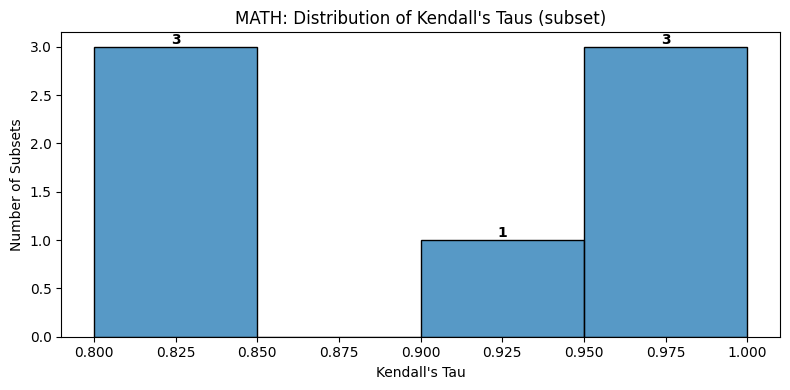

In [196]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=results_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel("Number of Subsets")
ax.set_title(f"{dataset}: Distribution of Kendall's Taus ({subset_col})")

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()

analysis = "subset_analysis"
plot_name = "kendall_tau_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### MMLU

Load the raw dataset and evaluation results.

In [197]:
dataset = "MMLU"
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
models = eval_results_df.columns.tolist()

print(f"Number of instances: {len(dataset_df)}")
display(dataset_df.head())
display(eval_results_df.head())

Number of instances: 14042


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1


,claude-3.5-haiku,gpt-3.5-turbo,gpt-4o-mini-2024-07-18,Llama-3.1-70B-Instruct,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-70B,Llama-3.1-Tulu-3-8B,Qwen2.5-72B-Instruct,Qwen2.5-7B-Instruct
0,1,0,1,1,0,1,0,1,0
1,0,0,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1
4,1,0,1,1,1,1,0,1,1


Compute each model's average performance across the entire dataset.

In [198]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)

print(f"Number of models: {len(mean_accuracy_df)}")
mean_accuracy_df.round(3).head()

Number of models: 9


,model,accuracy
3,Llama-3.1-70B-Instruct,0.853
7,Qwen2.5-72B-Instruct,0.850
5,Llama-3.1-Tulu-3-70B,0.819
2,gpt-4o-mini-2024-07-18,0.809
0,claude-3.5-haiku,0.808


Compute the global model ranking.

In [199]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

claude-3.5-haiku: 5
gpt-3.5-turbo: 8
gpt-4o-mini-2024-07-18: 4
Llama-3.1-70B-Instruct: 1
Llama-3.1-8B-Instruct: 7
Llama-3.1-Tulu-3-70B: 3
Llama-3.1-Tulu-3-8B: 9
Qwen2.5-72B-Instruct: 2
Qwen2.5-7B-Instruct: 6


Count the number of subsets where the local model ranking differs from the global model ranking.

In [200]:
subset_col = "subject"
subsets = dataset_df[subset_col].unique()

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Total number of subsets: 57
Subsets that differ from the global ranking: 56


Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [201]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

results_df = pd.DataFrame(results)
print(f"Number of subsets: {len(results_df)}")
results_df.head()

Computing model rankings: 100%|██████████| 57/57 [00:00<00:00, 944.16subset/s]

Number of subsets: 57


,subset,ranking,kendall_tau,n_instances
0,abstract_algebra,"[4, 8, 3, 2, 7, 4, 9, 1, 6]",0.873326,100
1,anatomy,"[5, 6, 1, 4, 7, 3, 9, 2, 8]",0.555556,135
2,astronomy,"[4, 9, 5, 2, 8, 1, 7, 3, 6]",0.722222,152
3,business_ethics,"[6, 7, 4, 1, 8, 2, 8, 2, 4]",0.841375,100
4,clinical_knowledge,"[5, 8, 4, 1, 7, 3, 9, 2, 6]",1.000000,265


Plot the distribution of Kendall's Taus between each subset's model ranking and the full dataset's model ranking.

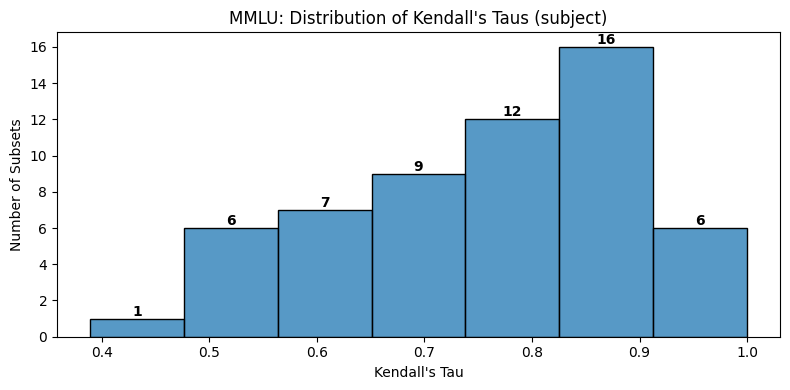

In [202]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=results_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel("Number of Subsets")
ax.set_title(f"{dataset}: Distribution of Kendall's Taus ({subset_col})")

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()

analysis = "subset_analysis"
plot_name = "kendall_tau_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()